**CREDIT CARD FRAUD DETECTION**

------------------------------------------------------------------------------------------------------------------------------------

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap mlflow jupyter notebook fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**STEP - 1 : DATA LOADING AND EDA**

In [ ]:
import pandas as pd                                         # importing pandas library
import numpy as np                                          # importing numpy library
import matplotlib.pyplot as plt                             # importing matplotlib for plotting
import seaborn as sns                                       # importing seaborn for visualization

import warnings                                             # importing warnings module
warnings.filterwarnings('ignore')                           # ignoring all warnings

print("Imports successful!")                                # confirming imports done

In [ ]:
df = pd.read_csv('creditcard.csv')                       # loading dataset into dataframe

print("Shape:", df.shape)                                # printing rows and columns count
print("\nColumn names:")                                 
print(df.columns.tolist())                               # printing all column names as list
print("\nFirst 5 rows:")                                 
df.head()                                                # displaying first 5 rows of dataset

Shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Class Distribution:")                                        # printing header
print(df['Class'].value_counts())                                   # counting legit vs fraud transactions

print("\nFraud Percentage:")                                        # printing header
fraud_pct = df['Class'].value_counts(normalize=True)[1] * 100       # calculating fraud percentage
print(f"{fraud_pct:.4f}%")                                          # printing fraud percentage upto 4 decimals

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
0.1727%


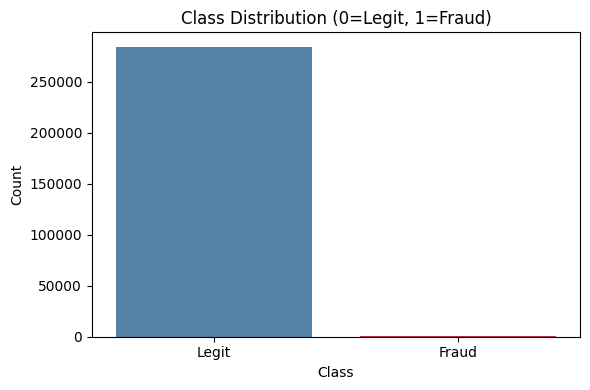

In [ ]:
plt.figure(figsize=(6, 4))                                              # setting figure size 6x4 inches
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])     # bar chart for class distribution
plt.title('Class Distribution (0=Legit, 1=Fraud)')                      # setting chart title
plt.xticks([0, 1], ['Legit', 'Fraud'])                                  # renaming x axis labels
plt.ylabel('Count')                                                     # setting y axis label
plt.tight_layout()                                                      # adjusting layout to prevent overlap
plt.show()                                                              # displaying the chart

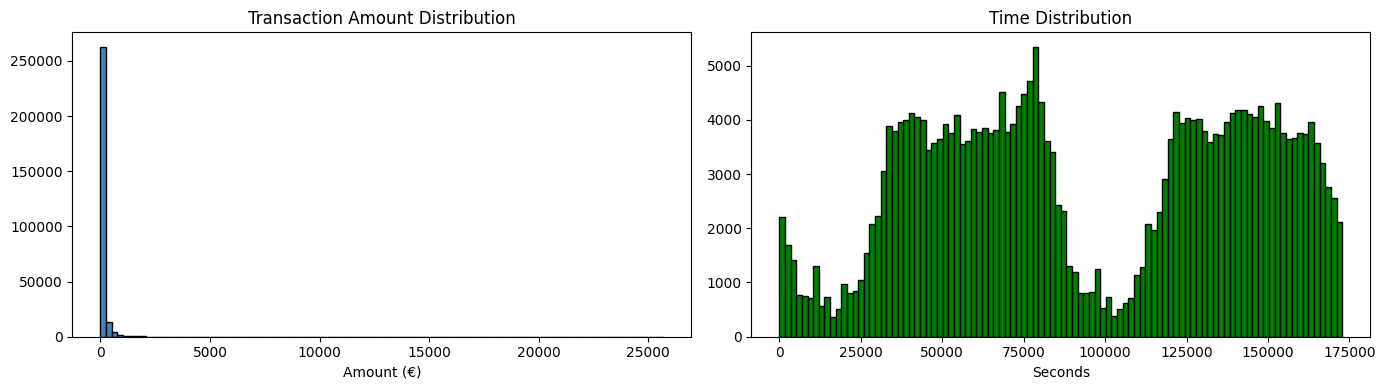

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))                             # creating 2 subplots side by side

axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='black')  # histogram for amount
axes[0].set_title('Transaction Amount Distribution')                        # setting title for amount chart
axes[0].set_xlabel('Amount (€)')                                            # setting x axis label for amount

axes[1].hist(df['Time'], bins=100, color='green', edgecolor='black')        # histogram for time
axes[1].set_title('Time Distribution')                                      # setting title for time chart
axes[1].set_xlabel('Seconds')                                               # setting x axis label for time

plt.tight_layout()                                                          # adjusting layout to prevent overlap
plt.show()                                                                  # displaying both charts

**STEP - 2 : PRE-PROCESSING**

In [ ]:
from sklearn.preprocessing import StandardScaler                # importing StandardScaler for feature scaling
from sklearn.model_selection import train_test_split            # importing train test split function

scaler = StandardScaler()                                       # creating StandardScaler object

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])      # scaling Amount column to standard range
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])        # scaling Time column to standard range

df.drop(['Amount', 'Time'], axis=1, inplace=True)               # dropping original unscaled columns

print("Scaling done!")                                          # confirming scaling complete
print("New shape:", df.shape)                                   # printing new shape after dropping columns
print("\nFirst 3 rows ki scaled values:")                
print(df[['Amount_Scaled', 'Time_Scaled']].head(3))             # displaying first 3 rows of scaled values

Scaling done!
New shape: (284807, 31)

First 3 rows ki scaled values:
   Amount_Scaled  Time_Scaled
0       0.244964    -1.996583
1      -0.342475    -1.996583
2       1.160686    -1.996562


In [ ]:
X = df.drop('Class', axis=1)                                # separating features from target
y = df['Class']                                             # separating target variable

X_train, X_test, y_train, y_test = train_test_split(        # splitting data into train and test sets
    X, y,
    test_size=0.2,                                          # 20% data for testing
    random_state=42,                                        # fixed random state for reproducibility
    stratify=y                                              # maintaining fraud ratio in both sets
)

print("✅ Split done!")                                     # confirming split complete
print(f"X_train: {X_train.shape}")                          # printing training data shape
print(f"X_test:  {X_test.shape}")                           # printing testing data shape
print(f"\nTrain mein fraud: {y_train.sum()}")               # counting fraud in training set
print(f"Test mein fraud:  {y_test.sum()}")                  # counting fraud in testing set

✅ Split done!
X_train: (227845, 30)
X_test:  (56962, 30)

Train mein fraud: 394
Test mein fraud:  98


**STEP - 3 : SMOTE (FIXING CLASS IMBALANCE)**

In [ ]:
from imblearn.over_sampling import SMOTE                                # importing SMOTE from imbalanced-learn library

smote = SMOTE(random_state=42)                                          # initializing SMOTE with random_state=42 for reproducibility

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)           # resampling training data to balance classes using SMOTE

print("SMOTE done!")                                                    # printing confirmation message after SMOTE
print(f"\nBefore SMOTE:")                                               # printing label for class distribution before SMOTE
print(f"  Legit  → {sum(y_train == 0)}")                                # printing count of legit transactions before SMOTE
print(f"  Fraud  → {sum(y_train == 1)}")                                # printing count of fraud transactions before SMOTE
print(f"\nAfter SMOTE:")                                                # printing label for class distribution after SMOTE
print(f"  Legit  → {sum(y_train_sm == 0)}")                             # printing count of legit transactions after SMOTE
print(f"  Fraud  → {sum(y_train_sm == 1)}")                             # printing count of fraud transactions after SMOTE

SMOTE done!

Before SMOTE:
  Legit  → 227451
  Fraud  → 394

After SMOTE:
  Legit  → 227451
  Fraud  → 227451


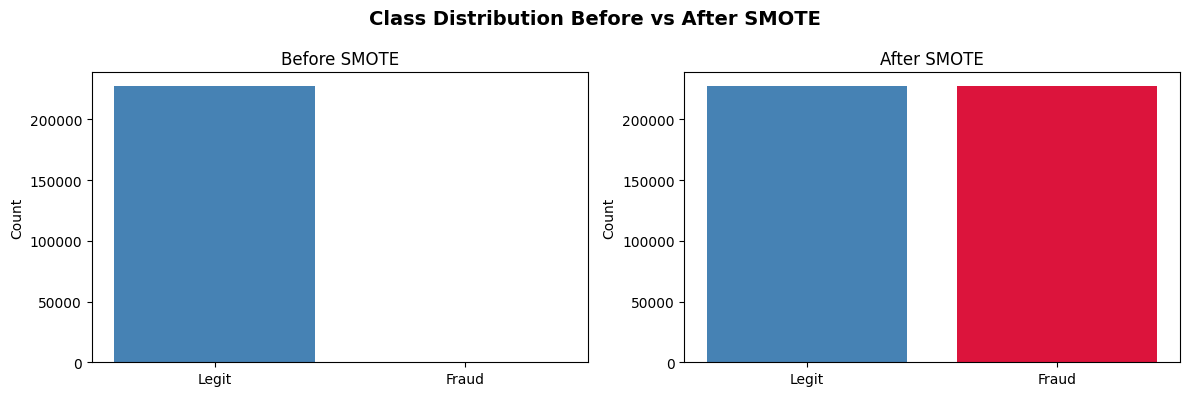

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))              # creating figure with 2 side-by-side subplots of size 12x4

# Before SMOTE
axes[0].bar(['Legit', 'Fraud'],                              # plotting bar chart for class distribution before SMOTE
            [sum(y_train == 0), sum(y_train == 1)],          # passing legit and fraud counts as bar heights
            color=['steelblue', 'crimson'])                  # setting bar colors for legit and fraud respectively
axes[0].set_title('Before SMOTE')                            # setting title for the first subplot
axes[0].set_ylabel('Count')                                  # setting y-axis label for the first subplot

# After SMOTE
axes[1].bar(['Legit', 'Fraud'],                              # plotting bar chart for class distribution after SMOTE
            [sum(y_train_sm == 0), sum(y_train_sm == 1)],    # passing resampled legit and fraud counts as bar heights
            color=['steelblue', 'crimson'])                  # setting same bar colors for consistency
axes[1].set_title('After SMOTE')                             # setting title for the second subplot
axes[1].set_ylabel('Count')                                  # setting y-axis label for the second subplot

plt.suptitle('Class Distribution Before vs After SMOTE',     # setting overall title for the entire figure
             fontsize=14, fontweight='bold')                 # setting font size and bold weight for the super title
plt.tight_layout()                                           # adjusting subplot spacing to prevent overlapping
plt.show()                                                   # displaying the final plot

**STEP - 4 : XGBOOTS TRAINING**

In [ ]:
import xgboost as xgb                                         # importing XGBoost library for gradient boosting classifier

model = xgb.XGBClassifier(                                    # initializing XGBoost classifier with custom hyperparameters
    n_estimators=100,                                         # number of boosting trees to build
    max_depth=4,                                              # maximum depth of each decision tree
    learning_rate=0.1,                                        # step size shrinkage to prevent overfitting
    scale_pos_weight=1,                                       # weight for positive class, set to 1 as SMOTE already balanced data
    random_state=42,                                          # seed for reproducibility
    eval_metric='logloss',                                    # evaluation metric used during training
    verbosity=0                                               # suppressing training logs and warnings
)

model.fit(X_train_sm, y_train_sm)                             # training the model on SMOTE resampled training data

print("XGBoost training complete!")                           # printing confirmation after model training is done

XGBoost training complete!


**STEP - 5 : MODEL EVALUATION**

In [ ]:
from sklearn.metrics import (classification_report,             # importing for detailed precision, recall, f1-score report
                              confusion_matrix,                 # importing for computing confusion matrix
                              roc_auc_score,                    # importing for calculating ROC-AUC score
                              roc_curve)                        # importing for generating ROC curve points

y_pred = model.predict(X_test)                                  # predicting class labels (0 or 1) for test data
y_prob = model.predict_proba(X_test)[:, 1]                      # extracting predicted probabilities for fraud class (class 1)

print("Predictions done!")                                      # printing confirmation after predictions are generated
print(f"Total predictions: {len(y_pred)}")                      # printing total number of predictions made
print(f"Fraud predicted:   {sum(y_pred)}")                      # printing count of transactions predicted as fraud
print(f"Actual fraud:      {sum(y_test)}")                      # printing count of actual fraud transactions in test set

Predictions done!
Total predictions: 56962
Fraud predicted:   547
Actual fraud:      98


In [ ]:
print("=" * 50)                                                   # printing a divider line of 50 equal signs
print("       MODEL EVALUATION REPORT")                           # printing centered report header title
print("=" * 50)                                                   # printing closing divider line of 50 equal signs
print(classification_report(y_test, y_pred,                       # printing detailed classification metrics for each class
      target_names=['Legit', 'Fraud']))                           # labeling classes as Legit and Fraud in the report
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")      # printing ROC-AUC score rounded to 4 decimal places
print("=" * 50)                                                   # printing final divider line to close the report

       MODEL EVALUATION REPORT
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     56864
       Fraud       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score: 0.9771


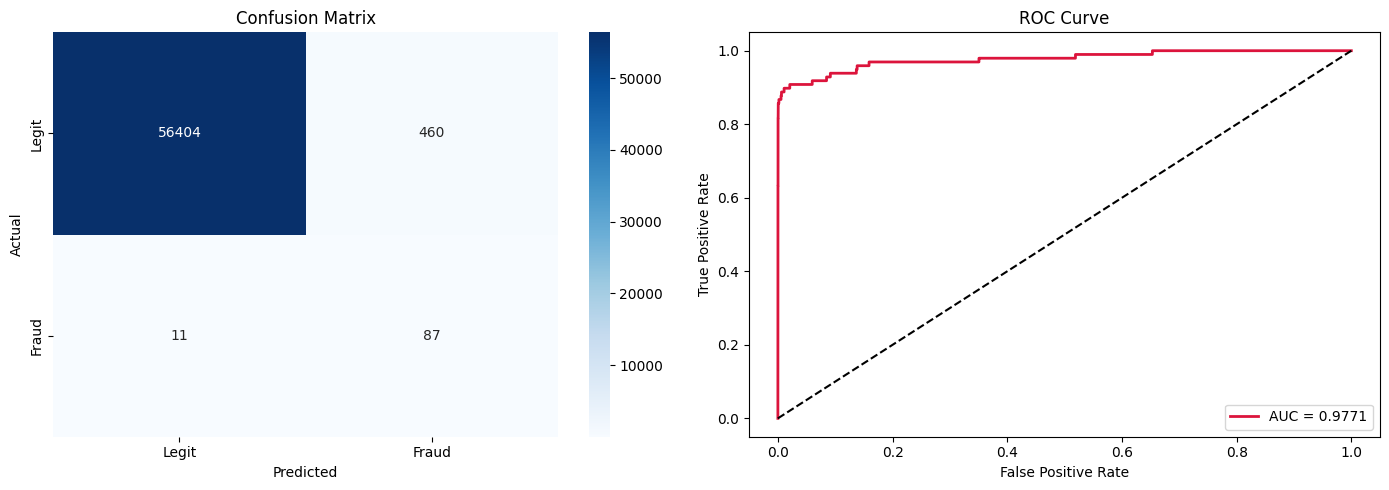

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))              # creating figure with 2 side-by-side subplots of size 14x5

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)                        # computing confusion matrix from actual and predicted labels
sns.heatmap(cm, annot=True, fmt='d',                         # plotting confusion matrix as heatmap with integer annotations
            cmap='Blues', ax=axes[0],                        # using Blues colormap and placing plot on first subplot
            xticklabels=['Legit', 'Fraud'],                  # setting x-axis labels as Legit and Fraud
            yticklabels=['Legit', 'Fraud'])                  # setting y-axis labels as Legit and Fraud
axes[0].set_title('Confusion Matrix')                        # setting title for confusion matrix subplot
axes[0].set_ylabel('Actual')                                 # setting y-axis label as Actual class
axes[0].set_xlabel('Predicted')                              # setting x-axis label as Predicted class

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)                      # computing false positive rate and true positive rate for ROC curve
auc_score   = roc_auc_score(y_test, y_prob)                  # calculating ROC-AUC score from actual labels and predicted probs
axes[1].plot(fpr, tpr, color='crimson',                      # plotting ROC curve in crimson color on second subplot
             lw=2, label=f'AUC = {auc_score:.4f}')           # setting line width and adding AUC score to legend label
axes[1].plot([0,1], [0,1], 'k--')                            # plotting diagonal dashed baseline representing random classifier
axes[1].set_title('ROC Curve')                               # setting title for ROC curve subplot
axes[1].set_xlabel('False Positive Rate')                    # setting x-axis label as False Positive Rate
axes[1].set_ylabel('True Positive Rate')                     # setting y-axis label as True Positive Rate
axes[1].legend()                                             # displaying legend with AUC score on the ROC curve plot

plt.tight_layout()                                           # adjusting spacing between subplots to prevent overlapping
plt.show()                                                   # rendering and displaying the complete figure

**STEP - 6 : SHAP EXPLAINABILITY**

In [ ]:
import shap                                                     # importing SHAP library for model explainability

explainer = shap.TreeExplainer(model)                           # initializing SHAP TreeExplainer optimized for tree-based models

X_test_sample = X_test.iloc[:500]                               # selecting first 500 rows from test set for SHAP analysis
shap_values = explainer.shap_values(X_test_sample)              # computing SHAP values for each feature in the sample

print("SHAP values calculated!")                             # printing confirmation after SHAP values are computed
print(f"Shape: {shap_values.shape}")                            # printing shape of SHAP values array for verification

SHAP values calculated!
Shape: (500, 30)


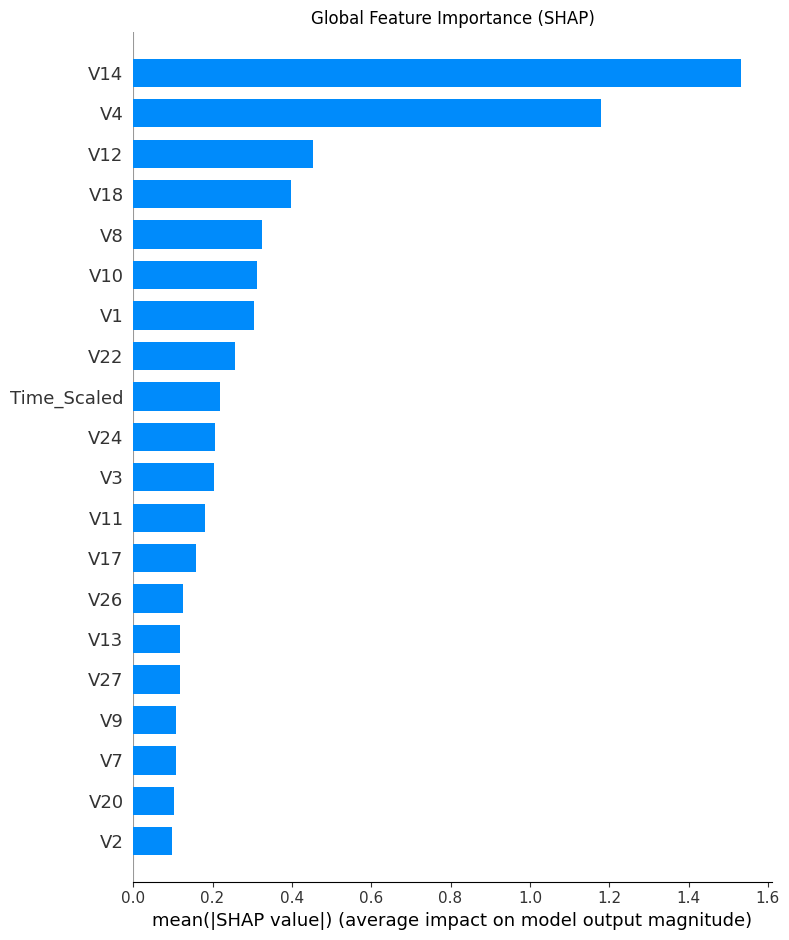

In [ ]:
plt.figure(figsize=(10, 6))                                  # creating a new figure with size 10x6 inches
shap.summary_plot(shap_values,                               # generating SHAP summary plot using computed SHAP values
                  X_test_sample,                             # passing sample test data for feature reference
                  plot_type='bar',                           # displaying plot as horizontal bar chart of mean SHAP values
                  show=False)                                # preventing SHAP from auto-displaying the plot
plt.title('Global Feature Importance (SHAP)')                # setting title to describe the plot as global feature importance
plt.tight_layout()                                           # adjusting layout to prevent overlapping elements
plt.show()                                                   # rendering and displaying the final SHAP importance plot

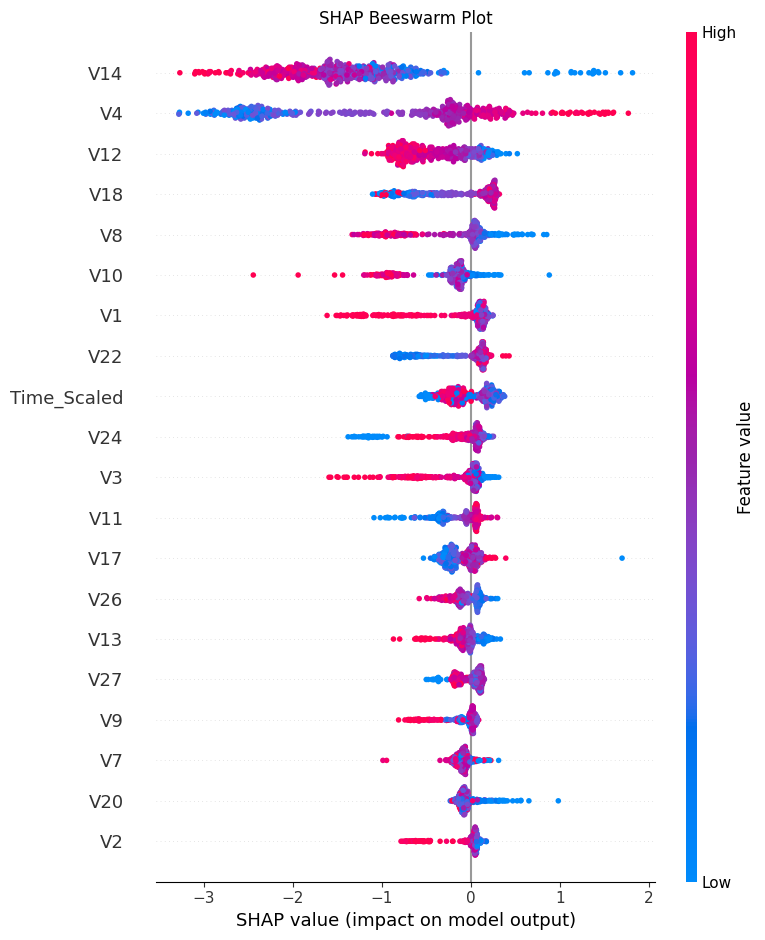

In [ ]:
plt.figure(figsize=(10, 6))                                  # creating a new figure with size 10x6 inches
shap.summary_plot(shap_values,                               # generating SHAP beeswarm plot using computed SHAP values
                  X_test_sample,                             # passing sample test data for feature and value reference
                  show=False)                                # preventing SHAP from auto-displaying the plot
plt.title('SHAP Beeswarm Plot')                              # setting title to describe the plot as SHAP beeswarm plot
plt.tight_layout()                                           # adjusting layout to prevent overlapping elements
plt.show()                                                   # rendering and displaying the final beeswarm plot

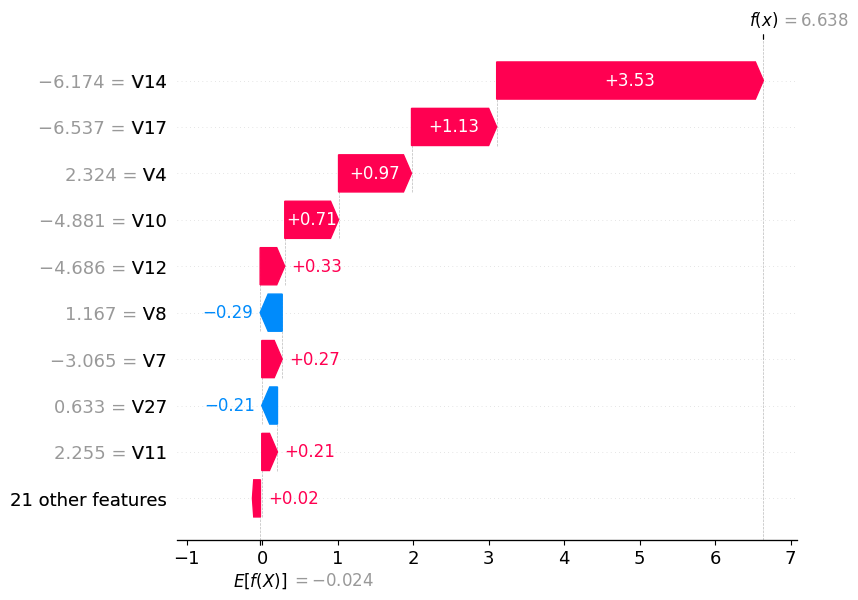

In [ ]:
fraud_indices = X_test[y_test == 1].index                       # extracting indices of all actual fraud transactions from test set
first_fraud   = X_test.loc[fraud_indices[0]:fraud_indices[0]]   # selecting the first fraud transaction as a single-row dataframe

shap_single = explainer.shap_values(first_fraud)                # computing SHAP values for the single fraud transaction

# Waterfall plot
shap.waterfall_plot(                                            # generating waterfall plot to explain single prediction
    shap.Explanation(                                           # creating SHAP Explanation object with required components
        values        = shap_single[0],                         # passing SHAP values for each feature of this transaction
        base_values   = explainer.expected_value,               # passing baseline expected value of the model output
        data          = first_fraud.iloc[0],                    # passing actual feature values of the fraud transaction
        feature_names = X_test.columns.tolist()                 # passing feature names for labeling the waterfall plot
    )
)

**STEP - 7 : ML FLOW EXPERINMENT TRACKING**

In [ ]:
import mlflow                                                           # importing MLflow for experiment tracking and logging
import mlflow.xgboost                                                   # importing MLflow XGBoost module for logging XGBoost models
from sklearn.metrics import f1_score, precision_score, recall_score     # importing metrics for model performance evaluation

mlflow.set_tracking_uri("http://127.0.0.1:5000")                        # setting MLflow tracking server URI to local server

# Experiment naam set karo
mlflow.set_experiment("Credit_Card_Fraud_Detection")                    # creating or setting experiment name in MLflow

# Run shuru karo
with mlflow.start_run(run_name="XGBoost_SMOTE_v1"):                     # starting a new MLflow run with a descriptive run name

    # Parameters log karo
    mlflow.log_param("model_type",     "XGBoost")                       # logging model type as a parameter
    mlflow.log_param("n_estimators",   100)                             # logging number of estimators as a parameter
    mlflow.log_param("max_depth",      4)                               # logging maximum tree depth as a parameter
    mlflow.log_param("learning_rate",  0.1)                             # logging learning rate as a parameter
    mlflow.log_param("smote_applied",  True)                            # logging whether SMOTE was applied as a parameter
    mlflow.log_param("test_size",      0.2)                             # logging test split size as a parameter

    # Metrics calculate karo
    f1        = f1_score(y_test, y_pred)                                # calculating F1 score from actual and predicted labels
    precision = precision_score(y_test, y_pred)                         # calculating precision score from actual and predicted labels
    recall    = recall_score(y_test, y_pred)                            # calculating recall score from actual and predicted labels
    auc       = roc_auc_score(y_test, y_prob)                           # calculating ROC-AUC score from actual labels and probabilities

    # Metrics log karo
    mlflow.log_metric("f1_score",  f1)                                  # logging F1 score to MLflow run
    mlflow.log_metric("precision", precision)                           # logging precision score to MLflow run
    mlflow.log_metric("recall",    recall)                              # logging recall score to MLflow run
    mlflow.log_metric("roc_auc",   auc)                                 # logging ROC-AUC score to MLflow run

    # Model save karo
    mlflow.xgboost.log_model(model, "xgboost_model")                    # saving and logging trained XGBoost model to MLflow

    print("MLflow run complete!")                                       # printing confirmation after successful MLflow logging
    print(f"F1 Score  : {f1:.4f}")                                      # printing F1 score rounded to 4 decimal places
    print(f"Precision : {precision:.4f}")                               # printing precision score rounded to 4 decimal places
    print(f"Recall    : {recall:.4f}")                                  # printing recall score rounded to 4 decimal places
    print(f"ROC-AUC   : {auc:.4f}")                                     # printing ROC-AUC score rounded to 4 decimal places

2026/04/04 17:31:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run complete!
F1 Score  : 0.2698
Precision : 0.1590
Recall    : 0.8878
ROC-AUC   : 0.9771
🏃 View run XGBoost_SMOTE_v1 at: http://127.0.0.1:5000/#/experiments/1/runs/4a2c5e97e6934fce81f26135d2ffd0d9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


**STEP - 8 : SMART UI LOGIC**

In [ ]:
import pickle                                                       # importing pickle library for serializing and saving python objects

with open('model.pkl', 'wb') as f:                                  # opening model.pkl file in write-binary mode
    pickle.dump(model, f)                                           # serializing and saving trained model to pickle file

with open('scaler.pkl', 'wb') as f:                                 # opening scaler.pkl file in write-binary mode
    pickle.dump(scaler, f)                                          # serializing and saving fitted scaler to pickle file

X_test.to_csv('X_test.csv', index=True)                             # saving test features to CSV file with index column
y_test.to_csv('y_test.csv', index=True)                             # saving test labels to CSV file with index column

print("Model, Scaler aur Test data saved!")                         # printing confirmation after all files are saved successfully

Model, Scaler aur Test data saved!


In [ ]:
df_original = pd.read_csv('creditcard.csv')                 # loading original dataset with Amount and Time columns intact
df_original['Hour'] = (df_original['Time'] / 3600) % 24     # converting Time seconds to hour of day (0-23)

print("Hour column added!")                                 # confirming hour column creation
print(df_original['Hour'].describe())                       # printing statistical summary of hour column

Hour column added!
count    284807.000000
mean         14.537951
std           5.847061
min           0.000000
25%          10.598194
50%          15.010833
75%          19.329722
max          23.999444
Name: Hour, dtype: float64


In [ ]:
import pickle                                               # importing pickle for saving python objects to disk
df_original = pd.read_csv('creditcard.csv')                 # loading original dataset with all columns
df_original['Hour'] = (df_original['Time'] / 3600) % 24     # converting Time seconds to hour of day (0-23)

with open('model.pkl', 'wb') as f:                          # opening model file in write binary mode
    pickle.dump(model, f)                                   # saving trained XGBoost model to disk
with open('scaler.pkl', 'wb') as f:                         # opening scaler file in write binary mode
    pickle.dump(scaler, f)                                  # saving fitted StandardScaler to disk

X_test.to_csv('X_test.csv', index=True)                     # saving test features to CSV with index
df_original.to_csv('df_original.csv', index=False)          # saving original dataset with hour column to CSV

print("Sab artifacts saved!")                            # confirming all artifacts saved successfully

Sab artifacts saved!
